In [2]:
import pyprogressive as pp
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
from pyprogressive import each, accum 

In [3]:
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

X1 = X["MedInc"]
X2 = X["HouseAge"]
X3 = X["AveRooms"]
X4 = X["AveBedrms"]

X1list = X1.tolist()
X2list = X2.tolist()
X3list = X3.tolist()
X4list = X4.tolist()

ylist = y.tolist()

arrayX1 = pp.array(X1list)
arrayX2 = pp.array(X2list)
arrayX3 = pp.array(X3list)
arrayX4 = pp.array(X4list)
arrayY = pp.array(ylist)



In [4]:
mean1 = accum(each(arrayX1)) / len(arrayX1)
mean2 = accum(each(arrayX2)) / len(arrayX2)
mean3 = accum(each(arrayX3)) / len(arrayX3)
mean4 = accum(each(arrayX4)) / len(arrayX4)
meanY = accum(each(arrayY)) / len(arrayY)

var1 = accum((each(arrayX1)-mean1)**2)/len(arrayX1)
var2 = accum((each(arrayX2)-mean2)**2)/len(arrayX2)
var3 = accum((each(arrayX3)-mean3)**2)/len(arrayX3)
var4 = accum((each(arrayX4)-mean4)**2)/len(arrayX4)
varY = accum((each(arrayY)-meanY)**2)/len(arrayY)

covX1Y = accum((each(arrayX1)-mean1)*(each(arrayY)-meanY)) / len(arrayX1)
covX2Y = accum((each(arrayX2)-mean2)*(each(arrayY)-meanY)) / len(arrayX2)
covX3Y = accum((each(arrayX3)-mean3)*(each(arrayY)-meanY)) / len(arrayX3)
covX4Y = accum((each(arrayX4)-mean4)*(each(arrayY)-meanY)) / len(arrayX4)


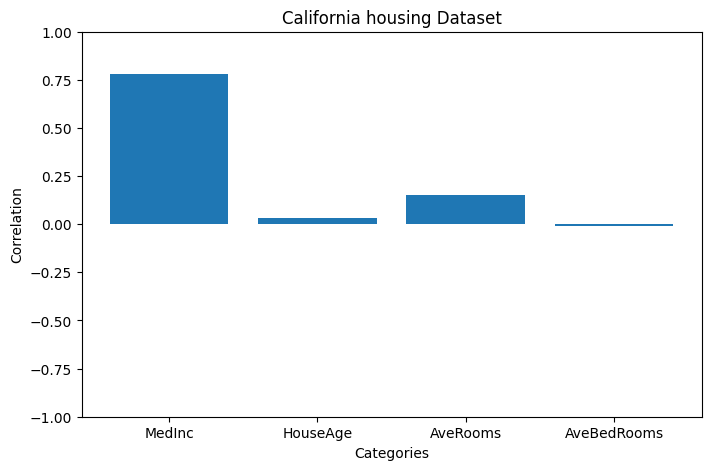

(time: 0.9928908999999919)


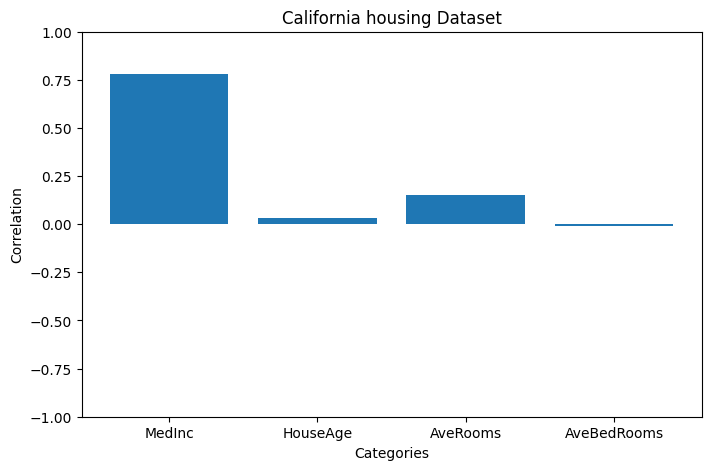

(time: 2.029260999999991)


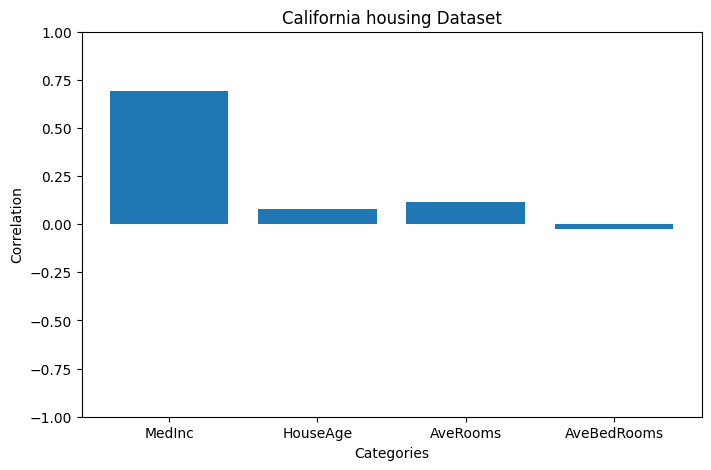

(time: 2.994371099999995)


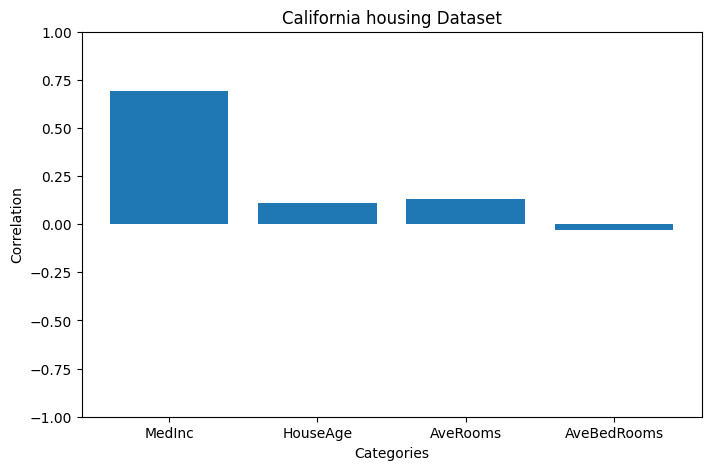

(time: 3.9979178000000104)


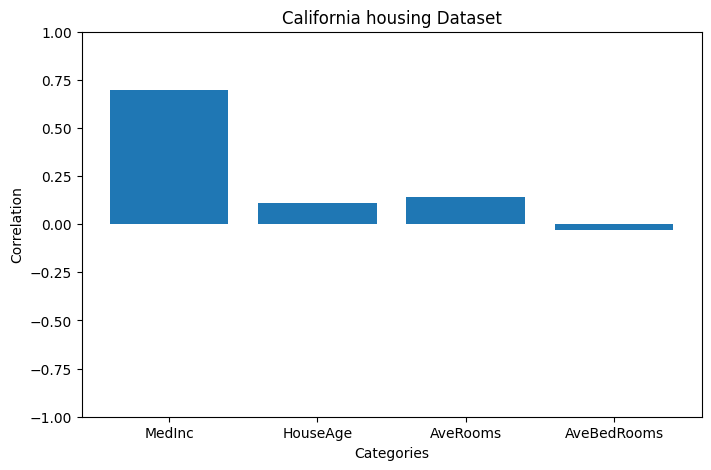

(time: 5.000534799999997)


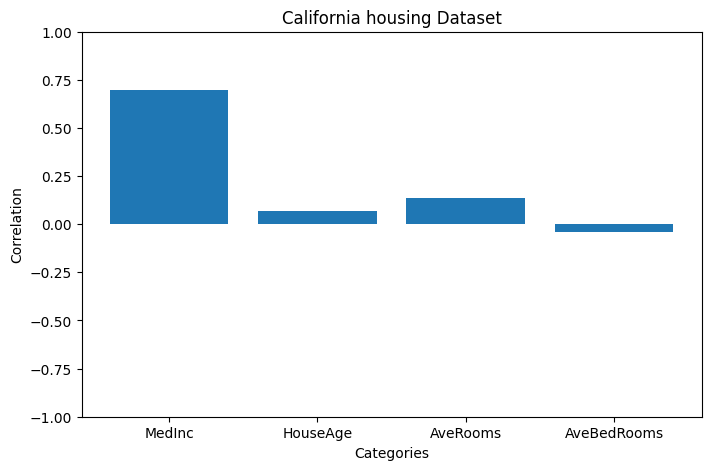

(time: 6.002912399999985)


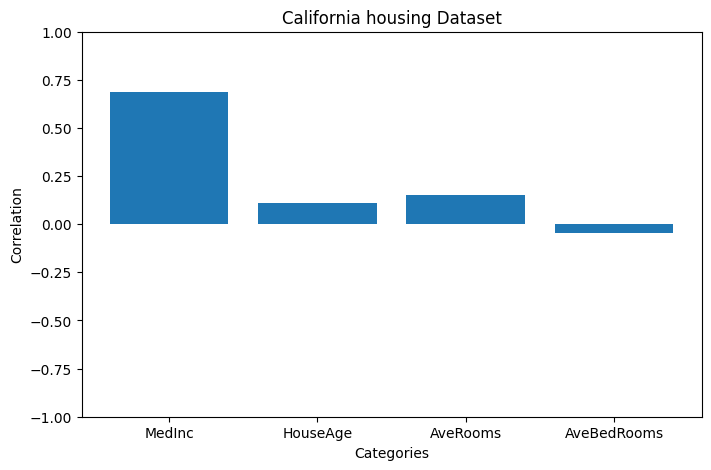

(time: 7.004976499999998)


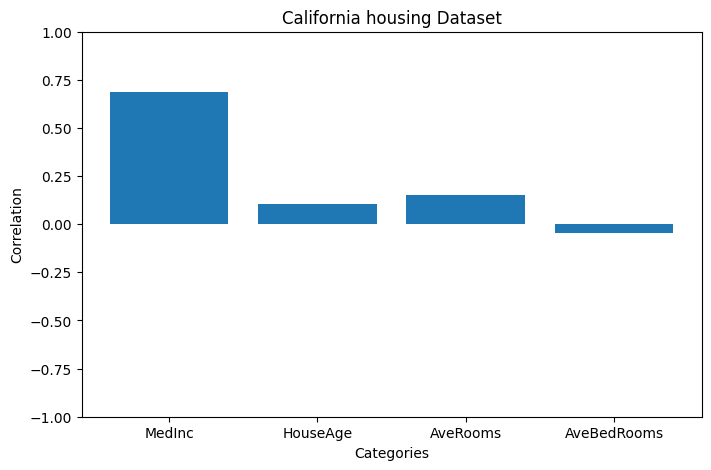

(time: 7.5302045999999905, complete)


In [5]:
def mycallback(cov1, cov2, cov3, cov4, var1, var2, var3, var4, varY, elapsed):
    corX1Y = (cov1/((var1**0.5)*(varY**0.5)+1e-8))
    corX2Y = (cov2/((var2**0.5)*(varY**0.5)+1e-8))
    corX3Y = (cov3/((var3**0.5)*(varY**0.5)+1e-8))
    corX4Y = (cov4/((var4**0.5)*(varY**0.5)+1e-8))
    categories = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedRooms']
    values = [corX1Y, corX2Y, corX3Y, corX4Y]
    plt.figure(figsize=(8, 5))
    plt.bar(categories, values)

    plt.title("California housing Dataset")
    plt.xlabel("Categories")
    plt.ylabel("Correlation")
    plt.ylim(-1, 1)

    plt.show()
    print(elapsed)

compiled = pp.compile(covX1Y, covX2Y, covX3Y, covX4Y, var1, var2, var3, var4, varY)
compiled.run(interval=1, callback = mycallback)